In [162]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [141]:
def CMYK_cal(R,G,B) :
    r = R/255.
    g = G/255.
    b = B/255.
    print(f"r = {r:.4f} , g = {g:.4f} , b = {b:.4f}")
    K = 1 - max(r,g,b)
    # C = (1-K-r)/(1.0000001-K)
    # M = (1-K-g)/(1.0000001-K)
    # Y = (1-K-b)/(1.0000001-K)
    C = 1 - r
    M = 1 - g
    Y = 1 - b
    K = min(C,M,Y)
    print(f"C = {C:.4f}")
    print(f"M = {M:.4f}")
    print(f"Y = {Y:.4f}")
    print(f"K = {K:.4f}")
    return [C,M,Y,K]

In [142]:
CMYK = CMYK_cal(200,255,255)

r = 0.7843 , g = 1.0000 , b = 1.0000
C = 0.2157
M = 0.0000
Y = 0.0000
K = 0.0000


In [143]:
CMYK = CMYK_cal(0,255,255)

r = 0.0000 , g = 1.0000 , b = 1.0000
C = 1.0000
M = 0.0000
Y = 0.0000
K = 0.0000


In [160]:
def RGB2CMYK(img) :
    R = img[:,:,0].astype('float16')/255.
    G = img[:,:,1].astype('float16')/255.
    B = img[:,:,2].astype('float16')/255.
    
    c = ((1 - R)*255).astype('uint8')
    m = ((1 - G)*255).astype('uint8')
    y = ((1 - B)*255).astype('uint8')
    k = np.minimum.reduce([c, m, y])
    return c,m,y,k

In [161]:
img = cv2.imread('../image/RGB_test.png')
rgb_img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
cmyk_img = RGB2CMYK(rgb_img)

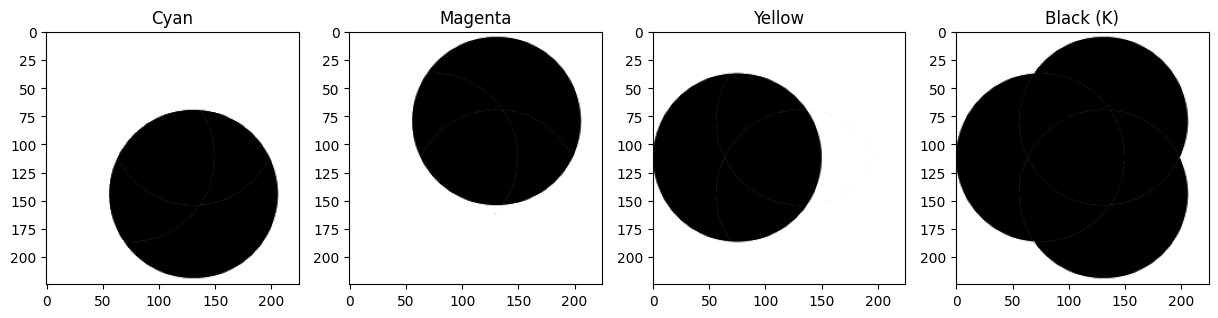

In [166]:
# แยก Tuple ออกมาเป็นตัวแปร
c, m, y, k = cmyk_img

# สร้างพื้นที่สำหรับ 4 รูป
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(c, cmap='gray')
plt.title('Cyan')

plt.subplot(1, 4, 2)
plt.imshow(m, cmap='gray')
plt.title('Magenta')

plt.subplot(1, 4, 3)
plt.imshow(y, cmap='gray')
plt.title('Yellow')

plt.subplot(1, 4, 4)
plt.imshow(k, cmap='gray')
plt.title('Black (K)')

plt.show()